In [4]:
import torch

if torch.cuda.is_available():
    print(f"CUDA is available! Found {torch.cuda.device_count()} GPU(s).")
else:
    print("CUDA is not available. PyTorch will use the CPU.")

CUDA is not available. PyTorch will use the CPU.


In [5]:
%env CUDA_VISIBLE_DEVICES=""

env: CUDA_VISIBLE_DEVICES=""


Loading and preprocessing data from ../0_data/pancreas_train.h5ad...
Loading and preprocessing data from ../0_data/pancreas_test.h5ad...

--- Running analysis for model: centralised_combined ---
INFO     File ../models/centralised_model/model.pt already downloaded                                              
Computing latent representations...
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
Computing neighbors and UMAP...
Celltype silhouette: 0.3194
Batch silhouette: -0.0569
Composite integration score: 0.6882

--- Running analysis for model: centralised_test ---
INFO     File ../models/centralised_model/model.pt already downloaded                                              
Computing latent representations...
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
Computing neighbors and UMAP...
Celltype silhouette: 0.4129
Batch silhouette: 0.0288
Composit

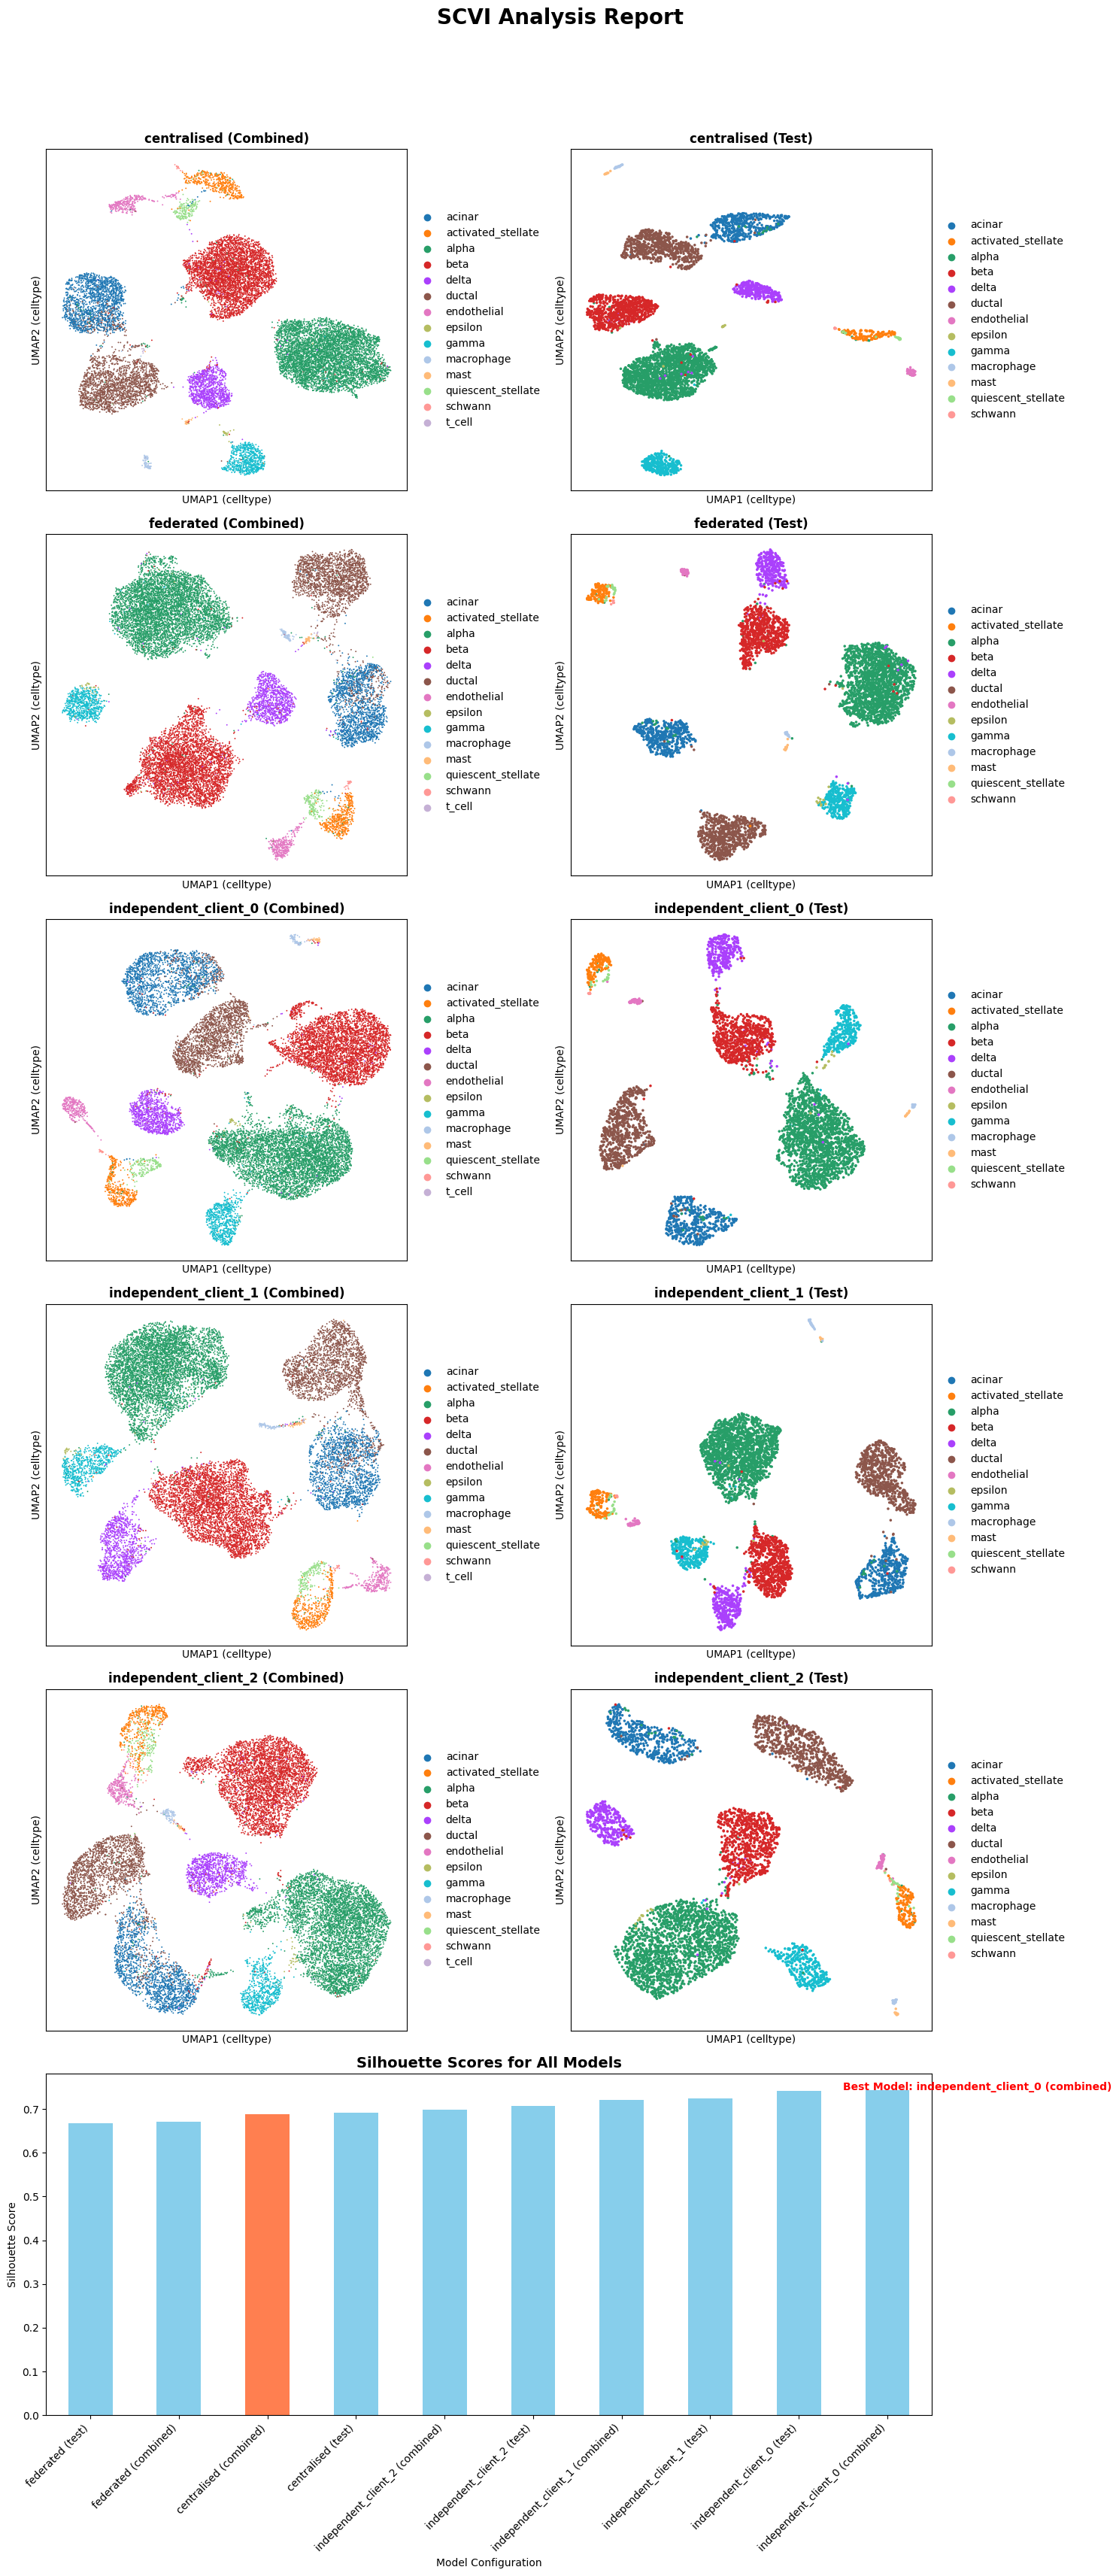



--- Final Summary of Silhouette Scores ---
|                      |   Combined Data |   Test Data |
|:---------------------|----------------:|------------:|
| centralised          |        0.688168 |    0.692021 |
| federated            |        0.670136 |    0.667292 |
| independent_client_0 |        0.743146 |    0.741591 |
| independent_client_1 |        0.7204   |    0.723409 |
| independent_client_2 |        0.698743 |    0.706581 |


In [ ]:
import os
import sys
import anndata
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from scvi.model import SCVI
from sklearn.metrics import silhouette_score
import torch
import pandas as pd

# The notebook is in a subdirectory, so we need to add the parent directory to the path
notebook_path = os.getcwd()
parent_path = os.path.abspath(os.path.join(notebook_path, '..'))
sys.path.append(parent_path)

from federated_scvi_flower.app.utils.model_utils_scvi import get_scvi_model, setup_scvi_anndata
from federated_scvi_flower.app.utils.data_utils_scvi import load_partitioned_anndata, ensure_hvg_genes, load_batch_list, load_hvg_list

def compute_latent_space(model: SCVI, adata_train: anndata.AnnData, adata_test: anndata.AnnData):
    """
    Computes the latent representation for both training and testing AnnData objects.
    """
    print("Computing latent representations...")
    latent_train = model.get_latent_representation()
    latent_test = model.get_latent_representation(adata_test)
    return latent_train, latent_test


def run_downstream_analysis(adata_combined: anndata.AnnData, use_rep: str = "X_scVI"):
    """
    Performs standard downstream analysis: computes neighbors, finds clusters with Leiden, and computes UMAP.
    """
    print("Computing neighbors and UMAP...")
    sc.pp.neighbors(adata_combined, use_rep=use_rep)
    sc.tl.leiden(adata_combined, flavor="igraph", n_iterations=2)
    sc.tl.umap(adata_combined)


# def evaluate_clustering(adata: anndata.AnnData, use_rep: str = "X_scVI", data_combined: bool = True, label_key: str = "leiden"):
#     """
#     Calculates the Silhouette Score to evaluate the quality of the clustering based on a specified label.
#     Returns the calculated score.
#     """
#     latent_data = adata.obsm[use_rep]
#     cluster_labels = adata.obs[label_key]

#     if len(np.unique(cluster_labels)) <= 1:
#         print(f"There are not enough clusters (<= 1) for label '{label_key}' to calculate the Silhouette Score.")
#         return None

#     combined_label = "train + test" if data_combined else "test"
#     score = silhouette_score(latent_data, cluster_labels)
#     print(f"Silhouette Score for {label_key} on {combined_label} data: {score:.4f}")
#     print(f"Number of unique labels found: {len(np.unique(cluster_labels))}")
#     return score

def evaluate_integration_score(adata: anndata.AnnData, use_rep: str = "X_scVI", data_combined: bool = True):
    """
    Computes celltype silhouette, batch silhouette, and a composite integration score.
    Composite = (celltype_score + (1 - batch_score)) / 2
    """
    latent_data = adata.obsm[use_rep]
    
    # Cell type silhouette
    celltype_labels = adata.obs["celltype"]
    if len(np.unique(celltype_labels)) <= 1:
        print("Not enough cell types for silhouette.")
        return None
    celltype_score = silhouette_score(latent_data, celltype_labels)
    
    # Batch silhouette
    batch_labels = adata.obs["batch"]
    if len(np.unique(batch_labels)) <= 1:
        print("Not enough batches for silhouette.")
        return None
    batch_score = silhouette_score(latent_data, batch_labels)
    
    composite_score = (celltype_score + (1 - batch_score)) / 2
    
    print(f"Celltype silhouette: {celltype_score:.4f}")
    print(f"Batch silhouette: {batch_score:.4f}")
    print(f"Composite integration score: {composite_score:.4f}")
    
    return composite_score

def run_analysis_pipeline(
    adata_train: anndata.AnnData,
    adata_test: anndata.AnnData,
    model_weights_path: str,
    data_combined: bool,
    save_dir: str = "../models",
    model_name: str = None,
):
    """
    Main function to run the full analysis pipeline for a given model.
    It returns the silhouette score and the processed AnnData object.
    """
    
    # Load model and set as trained
    if model_name:
        model = get_scvi_model(adata_train, hvg_list)
        print(f"Loading model weights from: {model_name}")
        state_dict = torch.load(model_name)
        if hasattr(model, "module"):
            model.module.load_state_dict(state_dict, strict=True)
        else:
            model.load_state_dict(state_dict, strict=True)
    else:
        model = SCVI.load(model_weights_path, adata_train)

    model.is_trained = True
    
    # Compute latent space and assign to AnnData objects
    latent_train, latent_test = compute_latent_space(model, adata_train, adata_test)
    adata_train.obsm["X_scVI"] = latent_train
    adata_test.obsm["X_scVI"] = latent_test
    
    # Prepare the combined or single dataset for downstream analysis
    if data_combined:
        adata_combined = anndata.concat(
            [adata_train, adata_test],
            label="dataset",
            keys=["train", "test"],
            join="inner",
            index_unique=None,
        )
        adata_combined.obsm["X_scVI"] = np.vstack([latent_train, latent_test])
    else:
        adata_combined = adata_test.copy()
        adata_combined.obsm["X_scVI"] = latent_test

    # Run clustering and evaluation, but not plotting here
    run_downstream_analysis(adata_combined, use_rep="X_scVI")
    score = evaluate_integration_score(adata_combined, use_rep="X_scVI", data_combined=data_combined)
    # score = evaluate_clustering(adata_combined, use_rep="X_scVI", data_combined=data_combined, label_key="celltype")
    
    return score, adata_combined


def load_and_preprocess_data(data_path: str, hvg_list: list, all_batches: list):
    """
    Loads an AnnData object, preprocesses it for SCVI, and sets up batch information.
    """
    print(f"Loading and preprocessing data from {data_path}...")
    adata = anndata.read_h5ad(data_path)
    adata.obs["batch"] = adata.obs.get("batch", adata.obs.get("tech", "batch0"))
    adata = ensure_hvg_genes(adata, hvg_list)
    setup_scvi_anndata(adata, all_batches=all_batches)
    return adata


def plot_umap_on_ax(ax, adata_obj, title_prefix, color_by_label):
    """
    Helper function to plot UMAPs on a given matplotlib axis with a correct title.
    """
    sc.pl.umap(adata_obj, color=color_by_label, ax=ax, show=False)
    ax.set_title(title_prefix, fontsize=12, fontweight='bold')
    ax.set_xlabel(f"UMAP1 ({color_by_label})")
    ax.set_ylabel(f"UMAP2 ({color_by_label})")

if __name__ == '__main__':
    # --- 1. Load and preprocess data only once ---
    save_dir = "../models"
    hvg_list = load_hvg_list("../0_data/hvg_list.json")
    all_batches = load_batch_list("../0_data/batch_list.json")

    adata_train = load_and_preprocess_data("../0_data/pancreas_train.h5ad", hvg_list, all_batches)
    adata_test = load_and_preprocess_data("../0_data/pancreas_test.h5ad", hvg_list, all_batches)
    name_prefix = "3_clients_20_rounds_5_epochs"

    # --- Initialize dictionaries to store results and AnnData objects for plotting ---
    results_combined = {}
    adata_combined_plots = {}
    
    results_test = {}
    adata_test_plots = {}
    
    # --- MODIFIED: Force color_by to be "celltype" ---
    color_by = "celltype"

    # --- 2. Define configurations for different analyses ---
    analysis_configs = {
        "centralised": {
            "model_weights_path": os.path.join(save_dir, "centralised_model"),
        },
        "federated": {
            "model_weights_path": os.path.join('..', "federated_scvi_flower/app/models", name_prefix),
            "model_name": os.path.join('..', "federated_scvi_flower/app/models", name_prefix, "model.pt"),
        },
    }
    
    # --- 3. Execute all analyses and collect results ---
    for config_name, config in analysis_configs.items():
        print(f"\n--- Running analysis for model: {config_name}_combined ---")
        score, adata_obj = run_analysis_pipeline(
            adata_train=adata_train,
            adata_test=adata_test,
            data_combined=True,
            **config
        )
        if score is not None:
            results_combined[config_name] = score
        if adata_obj is not None:
            adata_combined_plots[config_name] = adata_obj

        print(f"\n--- Running analysis for model: {config_name}_test ---")
        score, adata_obj = run_analysis_pipeline(
            adata_train=adata_train,
            adata_test=adata_test,
            data_combined=False,
            **config
        )
        if score is not None:
            results_test[config_name] = score
        if adata_obj is not None:
            adata_test_plots[config_name] = adata_obj

    # --- Handle independent clients with modified evaluation ---
    num_clients = 3
    # data_independent = [None for _ in range(num_clients)]
    # for c in range(num_clients):
        # data_independent[c] = load_partitioned_anndata(partition_id=c, num_partitions=num_clients, prefix='..')
        # data_independent[c].obs["batch"] = data_independent[c].obs.get("batch", data_independent[c].obs.get("tech", "batch0"))
        # data_independent[c] = ensure_hvg_genes(data_independent[c], hvg_list)
        # setup_scvi_anndata(data_independent[c], all_batches=all_batches)

    for id_client in range(num_clients):
        client_name = f"independent_client_{id_client}"
        model_path = os.path.join(save_dir, f"independent_client_{id_client}")
        
        # --- Use the full adata_train for the combined plot of independent clients ---
        print(f"\n--- Running analysis for model: {client_name}_combined (Modified) ---")
        score, adata_obj = run_analysis_pipeline(
            adata_train=adata_train,  # Use full training data as requested
            adata_test=adata_test,
            model_weights_path=model_path,
            data_combined=True
        )
        if score is not None:
            results_combined[client_name] = score
        if adata_obj is not None:
            adata_combined_plots[client_name] = adata_obj

        print(f"\n--- Running analysis for model: {client_name}_test ---")
        score, adata_obj = run_analysis_pipeline(
            adata_train=adata_train,
            adata_test=adata_test,
            model_weights_path=model_path,
            data_combined=False
        )
        if score is not None:
            results_test[client_name] = score
        if adata_obj is not None:
            adata_test_plots[client_name] = adata_obj

    print("\n--- Analysis pipeline completed successfully! ---")

    # --- Generate the Final Report with Plots and a Bar Chart ---
    print("\n--- Generating Final Report ---")
    
    # Prepare data for plotting UMAPs
    plot_labels = list(adata_combined_plots.keys())
    num_plots = len(plot_labels)

    # Create the figure with UMAP plots and a space for the bar chart
    fig, axes = plt.subplots(num_plots + 1, 2, figsize=(15, 6 * (num_plots + 1)))
    
    # Add a main title to the figure
    fig.suptitle("SCVI Analysis Report", fontsize=20, fontweight='bold')
    
    # Add column titles for clarity
    axes[0, 0].set_title("Combined (Train + Test) UMAPs", fontsize=14, fontweight='bold')
    axes[0, 1].set_title("Test Only UMAPs", fontsize=14, fontweight='bold')

    # Plot UMAPs in a two-column layout
    for i, title in enumerate(plot_labels):
        # Left column: Combined plots
        if title in adata_combined_plots:
            plot_umap_on_ax(axes[i, 0], adata_combined_plots[title], f"{title} (Combined)", color_by)

        # Right column: Test-only plots
        if title in adata_test_plots:
            plot_umap_on_ax(axes[i, 1], adata_test_plots[title], f"{title} (Test)", color_by)
    
    # Plot the bar chart in the bottom subplot
    all_results = {**{f"{k} (combined)": v for k, v in results_combined.items()},
                   **{f"{k} (test)": v for k, v in results_test.items()}}
    all_results_series = pd.Series(all_results)
    best_model = all_results_series.idxmax()
    colors = ['skyblue'] * len(all_results_series)
    colors[all_results_series.index.get_loc(best_model)] = 'coral'

    # Clear the axes for the bar plot and set it up
    ax_bar_row = axes[num_plots, :]
    for ax in ax_bar_row:
      ax.axis('off')
    
    ax_bar_single = fig.add_subplot(num_plots + 1, 1, num_plots + 1)
    all_results_series.sort_values().plot(kind='bar', ax=ax_bar_single, color=colors)
    ax_bar_single.set_title("Silhouette Scores for All Models", fontsize=14, fontweight='bold')
    ax_bar_single.set_ylabel("Silhouette Score")
    ax_bar_single.set_xlabel("Model Configuration")
    plt.xticks(rotation=45, ha="right")
    ax_bar_single.text(len(all_results_series) - 1.5, all_results_series.max(), f"Best Model: {best_model}", color='red', weight='bold')

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # --- Final results table at the end ---
    print("\n\n--- Final Summary of Silhouette Scores (composed) ---")
    results_df_combined = pd.DataFrame.from_dict(results_combined, orient='index', columns=["Combined Data"])
    results_df_test = pd.DataFrame.from_dict(results_test, orient='index', columns=["Test Data"])
    final_df = pd.concat([results_df_combined, results_df_test], axis=1)
    
    print(final_df.to_markdown())


### Why these results

The silhouette score is used to quantify how well-separated clusters are in the latent space, with higher values indicating tighter and more distinct grouping; it allows comparison of the structural separation achieved by different models regardless of ground truth labels. If one model achieves a higher silhouette score but also a higher test loss, it suggests that the model’s latent representation is more clustered but potentially less faithful in reconstructing the original data, indicating a trade-off between separation and generative accuracy.